In [1]:
import sys
sys.path.append("/mnt/nas05/data01/francesco/AIA2STIX/training")

from src.data.dataset import get_aia2stix_data_objects


/mnt/nas05/data01/francesco/AIA2STIX/training/src/vit.py:26: FutureWarning: xformers.components is deprecated and is not maintained anymore. It might be removed in a future version of xFormers 
  import xformers.components.attention.core as xfa


In [2]:
train_dataset, train_sampler, train_dl = get_aia2stix_data_objects(
    vis_path="/mnt/nas05/data01/francesco/AIA2STIX/Flarelist_visibilites.csv",
    data_path="/mnt/nas05/astrodata01/aia_2_stix/prepro_data_20250731_210359/processed_images",
    batch_size=1,
    distributed=False,
    num_data_workers=1,
    split='train',
    seed=42,
    enc_data_path="/mnt/nas05/astrodata01/aia_2_stix/encoded_data/",
    transform_vis=True
)

it = iter(train_dl)

In [3]:
batch = next(it)

In [7]:
inpt = batch[0].contiguous().float()
target_vis = batch[1].reshape(inpt.shape[0], 1, 24, 2)
enc_inpt = batch[2].reshape(inpt.shape[0], 1, 24, 2)

In [5]:
from src.utils import get_alpha

alpha = get_alpha(target_vis[0].numpy().squeeze())

In [6]:
target_vis / alpha

tensor([[[[ 1.7720, -0.4726],
          [ 0.9018, -1.2713],
          [ 1.7683, -0.9345],
          [ 1.7234, -0.4352],
          [ 1.5169, -0.7610],
          [ 1.0917,  0.3560],
          [ 1.2974, -1.0743],
          [ 1.5522, -0.0985],
          [ 0.4956, -0.8943],
          [-0.1454, -1.8058],
          [ 0.7683,  0.0613],
          [ 0.2449,  0.7949],
          [-0.2029,  0.3864],
          [ 0.7267,  0.2901],
          [ 0.0535, -0.7477],
          [ 0.0200, -0.1543],
          [-0.3156, -0.3931],
          [ 0.8512,  0.1793],
          [-0.3433,  0.1732],
          [-0.1296,  0.1281],
          [ 0.2224, -0.9805],
          [ 0.3414, -0.3147],
          [ 0.2291,  0.3224],
          [-0.0234,  0.4635]]]])

100%|██████████| 463/463 [00:01<00:00, 249.67it/s]


Mean: tensor([ 0.2554, -0.0007])
Std: tensor([0.3952, 0.3104])
Min: -0.9999805688858032
Max: 1.0
Median: 0.09339877218008041
Shape: torch.Size([463, 1, 24, 2])


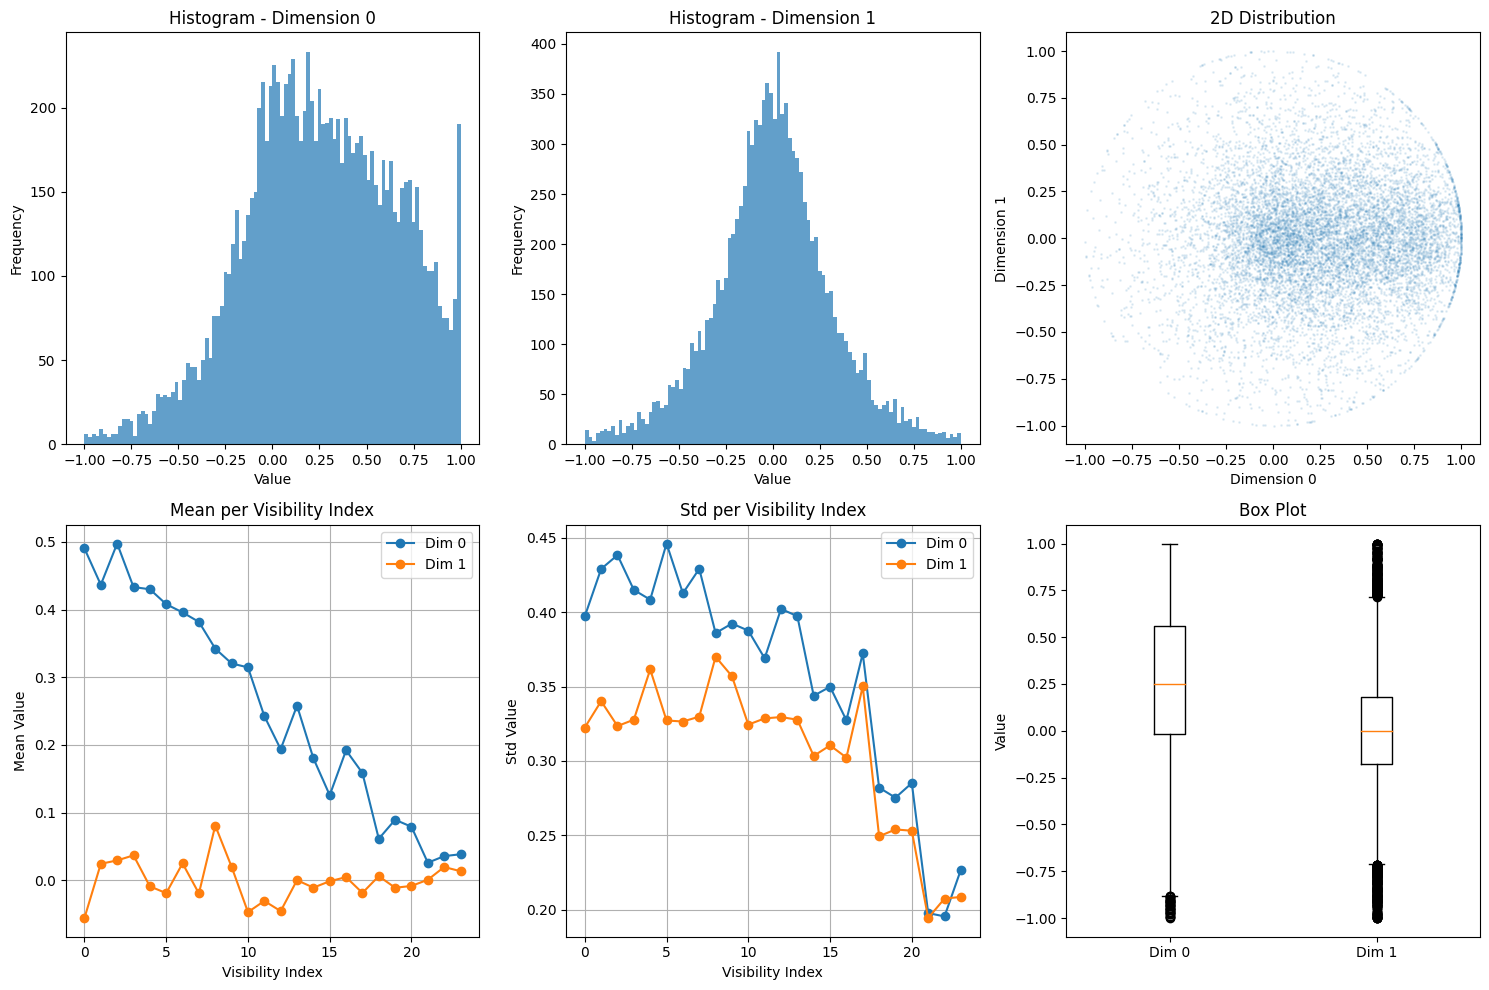

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm 
all_target_vis = []

for batch in tqdm(train_dl):
    target_vis = batch[1].reshape(batch[0].shape[0], 1, 24, 2)
    all_target_vis.append(target_vis)

all_target_vis = torch.cat(all_target_vis, dim=0)  # Shape: [N, 1, 24, 2]

# Compute metrics
mean = all_target_vis.mean(dim=(0, 1, 2))  # Mean per dimension [2]
std = all_target_vis.std(dim=(0, 1, 2))    # Std per dimension [2]
min_val = all_target_vis.min()
max_val = all_target_vis.max()
median = all_target_vis.median()

print(f"Mean: {mean}")
print(f"Std: {std}")
print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median}")
print(f"Shape: {all_target_vis.shape}")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Flatten data for histograms
data_flat = all_target_vis.reshape(-1, 2).cpu().numpy()

# Histogram for dimension 0
axes[0, 0].hist(data_flat[:, 0], bins=100, alpha=0.7)
axes[0, 0].set_title('Histogram - Dimension 0')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')

# Histogram for dimension 1
axes[0, 1].hist(data_flat[:, 1], bins=100, alpha=0.7)
axes[0, 1].set_title('Histogram - Dimension 1')
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Frequency')

# 2D scatter plot
axes[0, 2].scatter(data_flat[:, 0], data_flat[:, 1], alpha=0.1, s=1)
axes[0, 2].set_title('2D Distribution')
axes[0, 2].set_xlabel('Dimension 0')
axes[0, 2].set_ylabel('Dimension 1')

# Per-visibility statistics (24 visibilities)
vis_means = all_target_vis.mean(dim=0).squeeze().cpu().numpy()  # [24, 2]
axes[1, 0].plot(vis_means[:, 0], label='Dim 0', marker='o')
axes[1, 0].plot(vis_means[:, 1], label='Dim 1', marker='o')
axes[1, 0].set_title('Mean per Visibility Index')
axes[1, 0].set_xlabel('Visibility Index')
axes[1, 0].set_ylabel('Mean Value')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Per-visibility std
vis_stds = all_target_vis.std(dim=0).squeeze().cpu().numpy()  # [24, 2]
axes[1, 1].plot(vis_stds[:, 0], label='Dim 0', marker='o')
axes[1, 1].plot(vis_stds[:, 1], label='Dim 1', marker='o')
axes[1, 1].set_title('Std per Visibility Index')
axes[1, 1].set_xlabel('Visibility Index')
axes[1, 1].set_ylabel('Std Value')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Box plot
axes[1, 2].boxplot([data_flat[:, 0], data_flat[:, 1]], labels=['Dim 0', 'Dim 1'])
axes[1, 2].set_title('Box Plot')
axes[1, 2].set_ylabel('Value')

plt.tight_layout()
# plt.savefig('target_vis_distribution.png', dpi=150)
plt.show()

# Analysis on the latent space of the AIA images

100%|██████████| 463/463 [00:01<00:00, 244.35it/s]


Global Mean: -0.4657314121723175
Global Std: 0.2570086419582367
Min: -1.0
Max: 1.0
Median: -0.5038609504699707
Shape: torch.Size([463, 48])


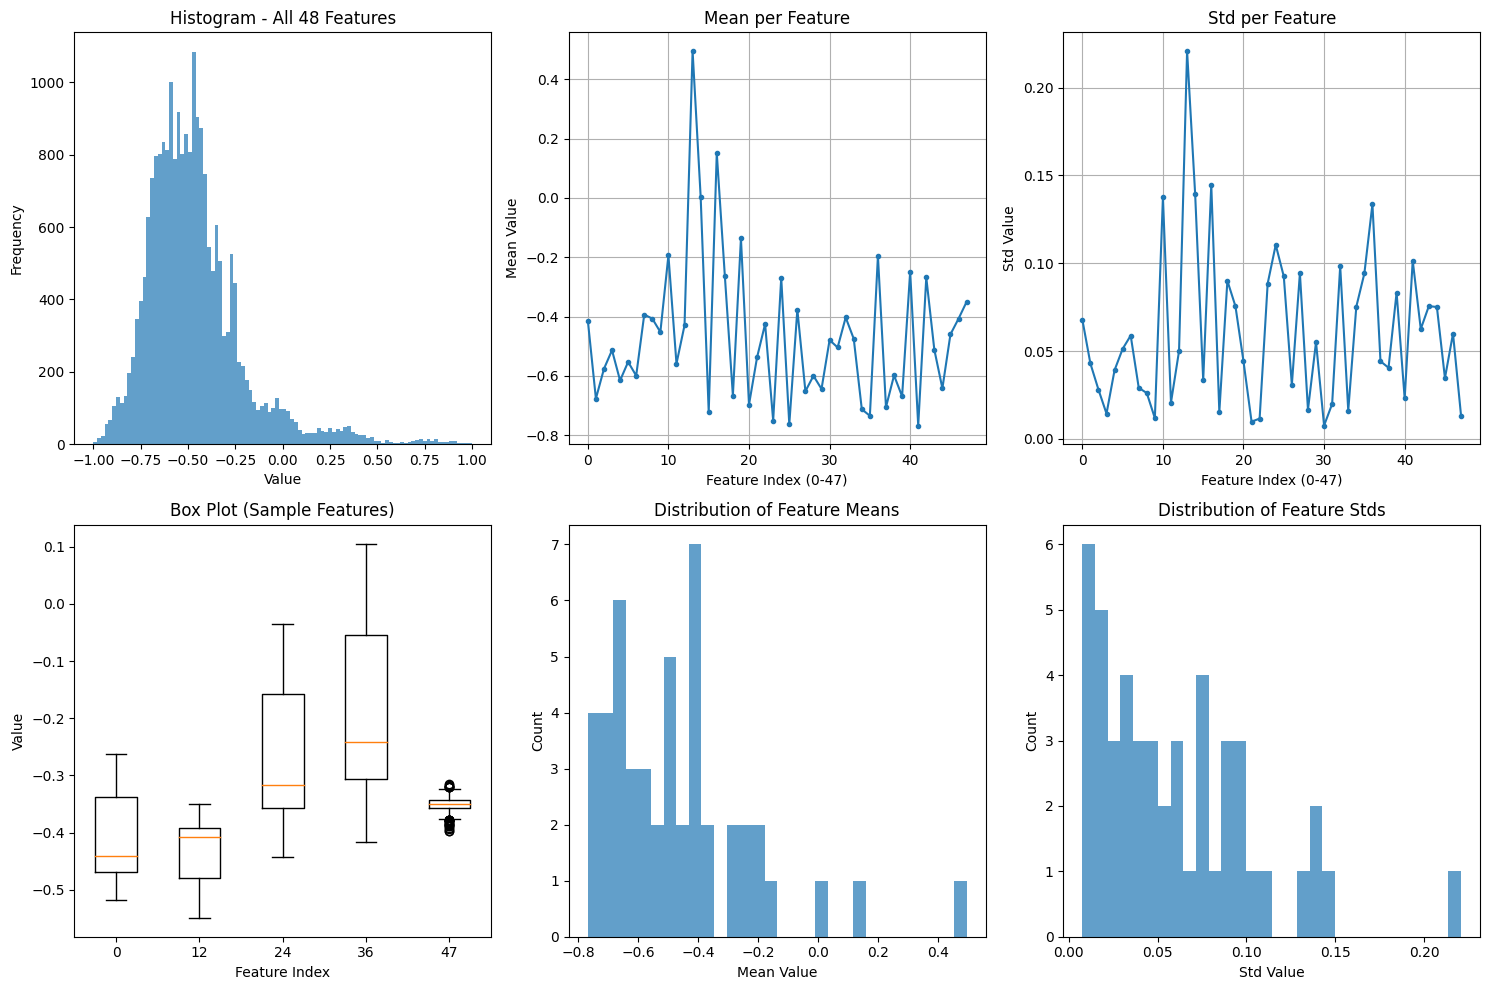

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

all_target_vis = []

for batch in tqdm(train_dl):
    target_vis = batch[2].reshape(batch[0].shape[0], 48)  # Flatten to (batch, 48)
    all_target_vis.append(target_vis)

all_target_vis = torch.cat(all_target_vis, dim=0)  # Shape: [N, 48]

# Compute metrics
mean = all_target_vis.mean(dim=0)  # Mean per feature [48]
std = all_target_vis.std(dim=0)    # Std per feature [48]
min_val = all_target_vis.min()
max_val = all_target_vis.max()
median = all_target_vis.median()

print(f"Global Mean: {all_target_vis.mean()}")
print(f"Global Std: {all_target_vis.std()}")
print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median}")
print(f"Shape: {all_target_vis.shape}")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Flatten all data for histogram
data_flat = all_target_vis.reshape(-1).cpu().numpy()

# Histogram of all values
axes[0, 0].hist(data_flat, bins=100, alpha=0.7)
axes[0, 0].set_title('Histogram - All 48 Features')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')

# Mean per feature (48 features)
axes[0, 1].plot(mean.cpu().numpy(), marker='o', markersize=3)
axes[0, 1].set_title('Mean per Feature')
axes[0, 1].set_xlabel('Feature Index (0-47)')
axes[0, 1].set_ylabel('Mean Value')
axes[0, 1].grid(True)

# Std per feature
axes[0, 2].plot(std.cpu().numpy(), marker='o', markersize=3)
axes[0, 2].set_title('Std per Feature')
axes[0, 2].set_xlabel('Feature Index (0-47)')
axes[0, 2].set_ylabel('Std Value')
axes[0, 2].grid(True)

# Box plot (sample of features)
sample_indices = [0, 12, 24, 36, 47]  # Sample 5 features
sample_data = [all_target_vis[:, i].cpu().numpy() for i in sample_indices]
axes[1, 0].boxplot(sample_data, labels=[f'{i}' for i in sample_indices])
axes[1, 0].set_title('Box Plot (Sample Features)')
axes[1, 0].set_xlabel('Feature Index')
axes[1, 0].set_ylabel('Value')

# Distribution of means
axes[1, 1].hist(mean.cpu().numpy(), bins=30, alpha=0.7)
axes[1, 1].set_title('Distribution of Feature Means')
axes[1, 1].set_xlabel('Mean Value')
axes[1, 1].set_ylabel('Count')

# Distribution of stds
axes[1, 2].hist(std.cpu().numpy(), bins=30, alpha=0.7)
axes[1, 2].set_title('Distribution of Feature Stds')
axes[1, 2].set_xlabel('Std Value')
axes[1, 2].set_ylabel('Count')

plt.tight_layout()
# plt.savefig('encoded_features_distribution.png', dpi=150)
plt.show()

In [10]:
import json

# After computing min_val and max_val
norm_stats = {
    'min': float(min_val),
    'max': float(max_val)
}

# Save to the encoded data directory
stats_path = '/mnt/nas05/data01/francesco/AIA2STIX/norm_stats_encoded.json'  # adjust path
with open(stats_path, 'w') as f:
    json.dump(norm_stats, f)

print(f"Saved normalization stats: min={norm_stats['min']}, max={norm_stats['max']}")

Saved normalization stats: min=-0.5325100421905518, max=1.44442880153656
